#### Connect to Zoneminder API

In [2]:
from pyzm.interface import ZMESConfig
from pyzm.interface import GlobalConfig, MLAPI_DEFAULT_CONFIG as DEFAULT_CONFIG
from pyzm.helpers.pyzm_utils import LogBuffer
from pyzm.api import ZMApi
import yaml


yaml_file_path = './yaml'
CONFIG_PATH = rf'{yaml_file_path}/objectconfig.yml'
SECRETS_LOCAL = rf'{yaml_file_path}/secrets.yml'
#g: GlobalConfig

# Load local secrets from yaml file
def LoadSecretsYAML(secrets_file: str) -> dict:
    with open(secrets_file, 'r') as file:
        secrets_yml = yaml.safe_load(file)
    return (secrets_yml)

global g
g = GlobalConfig()
g.logger = LogBuffer()

mlc: ZMESConfig = ZMESConfig(CONFIG_PATH, DEFAULT_CONFIG, "mlapi") 
g.config = mlc.config

# Set credentials
secret = LoadSecretsYAML(SECRETS_LOCAL)
api_options = {
    "apiurl": secret['secret']['ZM_API_PORTAL'],
    "portalurl": secret['secret']['ZM_PORTAL'],
    'user': secret['secret']['ZM_USER'],
    'password': secret['secret']['ZM_PASSWORD'],
    'basic_auth_user': secret['secret']['ZM_BASIC_USER'],
    'basic_auth_password': secret['secret']['ZM_BASIC_PASS']
}

# Connect to ZM-API
g.api = ZMApi(options=api_options)

# Check if connection is established
version = g.api.version()

print(f"ZM-Version: {version['zm_version']} - Status: {version['status']}")

ZM-Version: 1.36.33 - Status: ok


#### Query for zones for a specific monitor

In [3]:
import re

def getZoneCoordinates(MonID: int) -> list:
    mon_zone_coords = []

    # Get all zones
    list_of_zones = g.api.zones()

    for zone in list_of_zones:
        if (     (zone.zone['Zone']['MonitorId'] == MonID)
             #and (zone.zone['Zone']['Type'] == 'Active')
             and (zone.zone['Zone']['Type'] == 'Inactive')
             and (re.findall("event", zone.zone['Zone']['Name']))):

            mon_zone_coords.append(zone.zone['Zone']['Coords'])

    return mon_zone_coords

# Get Zone-Coordinates for Monitor ID No 9
zones_of_mid = 9
zone_coordinates = getZoneCoordinates(zones_of_mid)

print(f"Monitor: {zones_of_mid} - Zone-Coordinates: {zone_coordinates}")


Monitor: 9 - Zone-Coordinates: ['1088,320 1183,118 1835,73 1611,625 1236,552 785,773 859,341']


In [4]:
from  pprint import pprint
list_of_zones = g.api.zones()
list_of_zones = sorted(list_of_zones, key=lambda x: x.zone['Zone']['MonitorId'])
for zone in list_of_zones:
    print(f"{zone.zone['Zone']['MonitorId']:4} - {zone.zone['Zone']['Name']:20} - {zone.zone['Zone']['Type']}")
    

   3 - All                  - Active
   3 - for event notify     - Inactive
   4 - All                  - Active
   7 - All                  - Active
   8 - All                  - Active
   9 - zone-1               - Active
   9 - MID-9-zm-event       - Inactive
   9 - zone-3               - Inactive
  10 - All                  - Active
  11 - All                  - Active
  12 - All                  - Active


#### Draw zones into blank picture

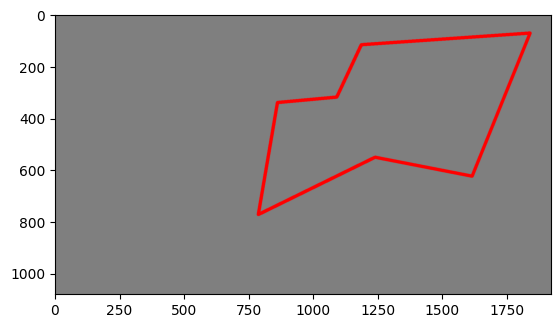

In [5]:
import numpy as np
import cv2
import imutils
import matplotlib.pyplot as plt
from pathlib import Path

# get size of image of a specific monitor
home = str(Path.home())
image = cv2.imread(home + '/Development/zm-programming/objdet_pynb/pictures/zones_object_detection/00072-capture.jpg')

height, width, c = image.shape
gray_level = 127
blank_image = gray_level * np.ones(shape=(height, width, c), dtype=np.uint8)

### Rectangle definition
def draw_rectangle(image, x, y, width, height):
    cv2.rectangle(image, (x, y), (x + width, y + height), (255,0,0), thickness=12)

def draw_rectangle_color(image, x, y, width, height, color=(255,0,0)):
    cv2.rectangle(image, (x, y), (x + width, y + height), color, thickness=12)

def draw_polygon(image, ptr: list):
    pts = np.array(ptr, np.int32)    
    cv2.polylines(image, [pts], True, (255,0,0), thickness=12)
### Rectangle definition end

for zones in zone_coordinates:
    zones_pts = zones.split(' ')
    zones_pts = [list(map(int, x.split(','))) for x in zones_pts]
    draw_polygon(blank_image, zones_pts)

plt.imshow(blank_image)


#### Assuming there is a yolo finding

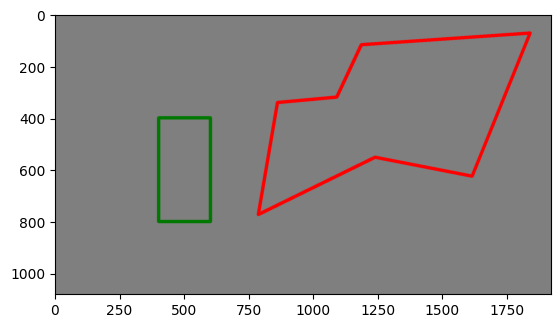

In [6]:
draw_rectangle_color (blank_image,  400,  400,  200,  400, (0, 120, 0))

plt.imshow(blank_image)

There are 2 objects here.
No Person in Zone detected


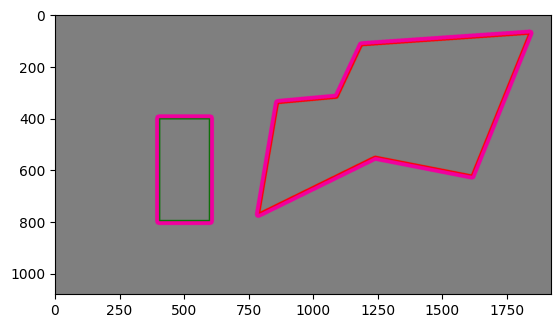

In [7]:
# convert  the image to a grayscale type
gray_scaled = cv2.cvtColor(blank_image, cv2.COLOR_BGR2GRAY)

# Thresholding the image
thresh = cv2.threshold(gray_scaled, 125, 125, cv2.THRESH_BINARY_INV)[1]

# detecting and drawing contours
contours = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = imutils.grab_contours(contours)

output = blank_image.copy()

# loop over each contour found
for contour in contours:
    # outline and display them, one by one.
    cv2.drawContours(output, [contour], -1, (240, 0, 159), 13) 

plt.imshow(output)

print (f"There are {len(contours)} objects here.")
if len(contours) > len(zone_coordinates):
    print ("No Person in Zone detected")
else:
    print ("Person in Zone detectd")

### Assuming there is another yolo finding

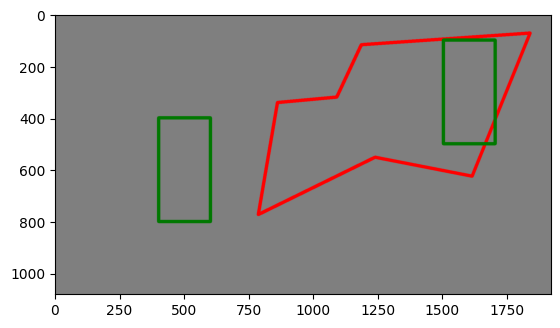

In [8]:
draw_rectangle_color (blank_image,  1500,  100,  200,  400, (0, 120, 0))

plt.imshow(blank_image)


There are 2 objects here.
Person in Zone detectd


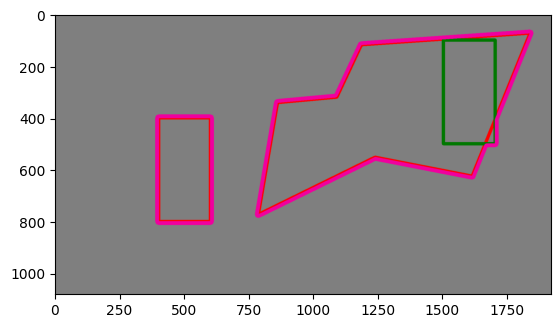

In [9]:
draw_rectangle (blank_image,  400,  400,  200,  400)

# convert to a grayscale
gray_scaled = cv2.cvtColor(blank_image, cv2.COLOR_BGR2GRAY)

# Thresholding the image
thresh = cv2.threshold(gray_scaled, 125, 125, cv2.THRESH_BINARY_INV)[1]

# Detecting and drawing contours
contours = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = imutils.grab_contours(contours)
output = blank_image.copy()

# loop over each contour found
for contour in contours:
    cv2.drawContours(output, [contour], -1, (240, 0, 159), 13) 

plt.imshow(output)

print (f"There are {len(contours)} objects here.")
if len(contours) > len(zone_coordinates) + 1: # + 1 from above finding
    print ("No Person in Zone detected")
else:
    print ("Person in Zone detectd")

### Final implementation

In [10]:
import numpy as np
import cv2
import imutils
import matplotlib.pyplot as plt
from pathlib import Path
from image_file_handling import *

#
# Input information
#
EventID = 25327
EventsFolder = '/mnt/DiskVerbatimVi55/ZMEvents'

# take size from riginal image
Event, Monitor, Frame = g.api.get_all_event_data(EventID)
mid = Monitor['Id']

event_folder = getEventFolder(EventsFolder, EventID)

json_data = LoadObjectsJson(event_folder)
image_obj = cv2.imread(event_folder + '/' + 'objdetect.jpg')
height, width, c = image_obj.shape

# create blank_image
gray_level = 127
blank_image = gray_level * np.ones(shape=(height, width, c), dtype=np.uint8)

labels = json_data['labels']
boxes = json_data['boxes']
object_boxes_list=[]
for counter, value in enumerate(labels, start=0):
    print(counter, value)
    #if value == 'person':
    if value in g.config['object_detection_pattern']:
        object_boxes_list.append(boxes[counter])

print(f"Object boxes: {object_boxes_list}")


# Get Zone-Coordinates for Monitor ID
zone_coordinates = getZoneCoordinates(mid)
print (f"zone_coordinates: {zone_coordinates}")

for zones in zone_coordinates:
    zones_pts = zones.split(' ')
    zones_pts = [list(map(int, x.split(','))) for x in zones_pts]
    draw_polygon(blank_image, zones_pts)

print(f"Monitor: {mid} - Zone-Coordinates: {zone_coordinates}")


0 person
1 person
2 person
Object boxes: [[1176, 348, 1566, 1084], [562, 388, 1072, 1084], [1229, 140, 1487, 634]]
zone_coordinates: ['1248,0 1780,0 1639,1079 988,1072']
Monitor: 3 - Zone-Coordinates: ['1248,0 1780,0 1639,1079 988,1072']


In [11]:
# API call to get all zones
Event, Monitor, Frame = g.api.get_all_event_data(EventID)
event_folder = Event["FileSystemPath"]

# file search
#event_folder = getEventFolder(event_folder, EventID)

# open the folder in file manager
!caja $event_folder

In [12]:
import numpy as np
import cv2
import imutils
import matplotlib.pyplot as plt
from pathlib import Path
from image_file_handling import *

person_zone_state=list()
image_list = []

for object_box_counter, object_box in enumerate(object_boxes_list):

    blank_image = gray_level * np.ones(shape=(height, width, c), dtype=np.uint8)

    draw_polygon(blank_image, zones_pts)

    draw_rectangle_color(blank_image, 
                        object_box[0], 
                        object_box[1], 
                        object_box[2]-object_box[0], 
                        object_box[3]-object_box[1], 
                        (0, 120, 0))

    # convert  the image to a grayscale type
    gray_scaled = cv2.cvtColor(blank_image, cv2.COLOR_BGR2GRAY)

    # Thresholding the image
    thresh = cv2.threshold(gray_scaled, 125, 125, cv2.THRESH_BINARY_INV)[1]

    # find the contours in the thresholded image
    contours = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = imutils.grab_contours(contours)

    image_out = blank_image.copy()
    for contour in contours:
        # display one by one.
        cv2.drawContours(image_out, [contour], -1, (240, 0, 159), 10) 

    # weighted input image and the overlay
    image_out = result = cv2.addWeighted(image_out, .5, image_obj, .5, 0)

    image_list.append(image_out)

    #print (f"No objects {len(contours)}")
    if len(contours) > len(zone_coordinates):
        person_zone_state.append({object_box_counter : 'Outside'})
    else:
        person_zone_state.append({object_box_counter: 'Inside'})

print (person_zone_state)

[{0: 'Inside'}, {1: 'Inside'}, {2: 'Inside'}]


### Draw zones on images

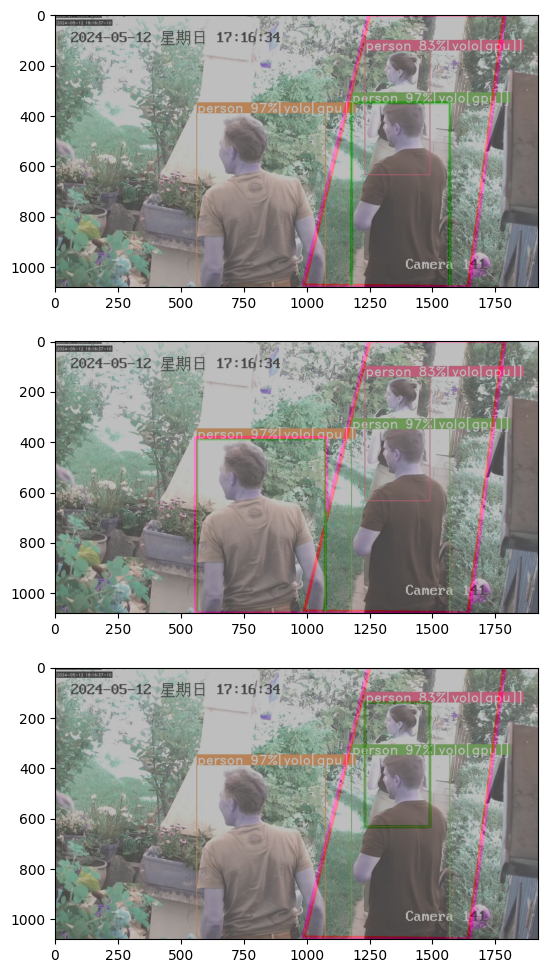

In [13]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

path_object_zones = './pictures/zones_object_detection/objdetect_zones'

# figure size in inches
rcParams['figure.figsize'] = 10,10

cols = 1
rows = len(image_list)

# display images
fig, axes = plt.subplots(rows, cols, figsize=(16,12))

for i, img in enumerate(image_list): 
    cv2.imwrite( f'{path_object_zones}_{i}.jpg', img)
    axes[i].imshow(img)


zone_state: {0: 'Inside'}
zone_state: Inside
zone_state: {1: 'Inside'}
zone_state: Inside
zone_state: {2: 'Inside'}
zone_state: Inside


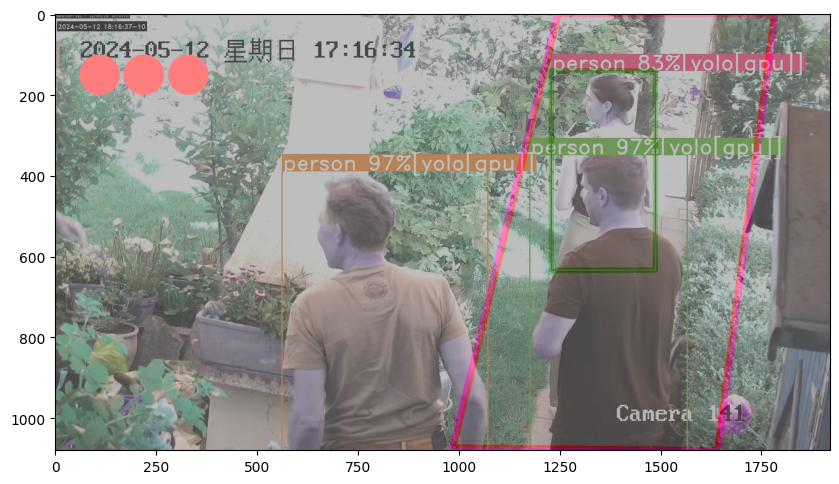

In [14]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
from networkx import center

path_object_zones = './pictures/zones_object_detection/objdetect_zones'

image_paint = image_out.copy()

for number, zone_state in enumerate(person_zone_state):

    radius = 50

    center_x = (number+1) * (radius*2) + ((number+1)*10)

    # Center coordinates 
    center_coordinates = (center_x, 150)

    # Radius of circle 

    print(f"zone_state: {zone_state}")
    print(f"zone_state: {list(zone_state.values())[0]}")

    if list(zone_state.values())[0] == 'Inside':
        # Red color in RGB 
        color = (255, 125, 125) 
    else:
        # Red color in RGB 
        color = (125, 255, 125) 
    
    # Line thickness of -1 px 
    thickness = -1
    
    # Using cv2.circle() method 
    # Draw a circle of red color of thickness -1 px 
    image_paint = cv2.circle(image_paint, center_coordinates, radius, color, thickness) 

    plt.imshow(image_paint)

### Use import to get the function

In [17]:
# Run cell 1 -  Connect to Zoneminder API
import json
from pprint import pprint
with open('zones_object_detection.ipynb', 'r') as content_file:
    content = content_file.read()
#print (content)

data=json.loads(content)

data["cells"][1]
print (data["cells"][1]["source"][0:3])
#print (data["cells"][1])


['#import os\n', '#import sys \n', 'from pyzm.interface import ZMESConfig\n']


In [16]:
# main program
import zone_Obj_Locaction as zol
#import zone_Obj_Locaction as zol
from pyzm.interface import GlobalConfig, MLAPI_DEFAULT_CONFIG as DEFAULT_CONFIG


object_loacation = zol.ObjLocaction(g, EventID=25327)
MonID = object_loacation.Monitor['Id']
print(f"Monitor: {MonID}")

zone_coords = object_loacation.getZoneCoordinates(MonID)
print(zone_coords)

width, hight, _ = object_loacation.get_Event()
print(width, hight)

# zone_coordinates:list, width:int, height:int, person_box:list):

#object_loacation.calc_location()

# if object_loacation.obj_state == object_loacation.obj_state.inside_zone:
#     print('inside_zone')

# print ("ttt:     ", object_loacation.obj_state.value)
# print ("ttt:     ", object_loacation.obj_state.name)


ModuleNotFoundError: No module named 'zone_Obj_Locaction'